In [1]:
from __future__ import print_function
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml
np.random.seed(11)
from mnist import MNIST
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm
import time
from scipy import io

# 1. Phần mô hình K- trung bình (K-Means model)

## Ví dụ 1

### 1.1 Thực hiện bằng numpy

Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


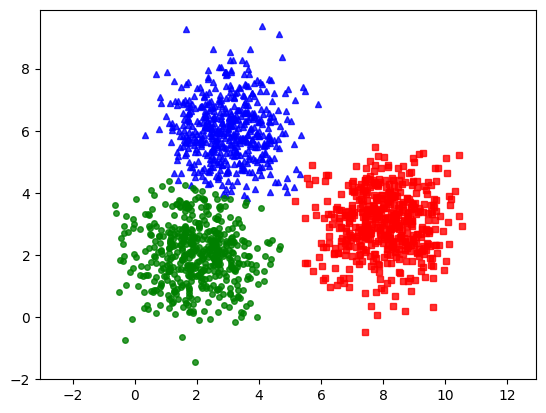

In [2]:
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]

# Số điểm mỗi cụm dữ liệu
N = 500
# Tạo các cụm dữ liệu qua phân bố chuẩn (Gaussian)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
# Tổng hợp dữ liệu từ các cụm
X = np.concatenate((X0, X1, X2), axis = 0)
# Số cụm = 3
K = 3
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)
    plt.axis('equal')
    plt.plot()
    plt.show()

def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])
kmeans_display(X, labels[-1])

### 1.2. Thực hiện bằng sklearn

Centers found by scikit-learn:
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


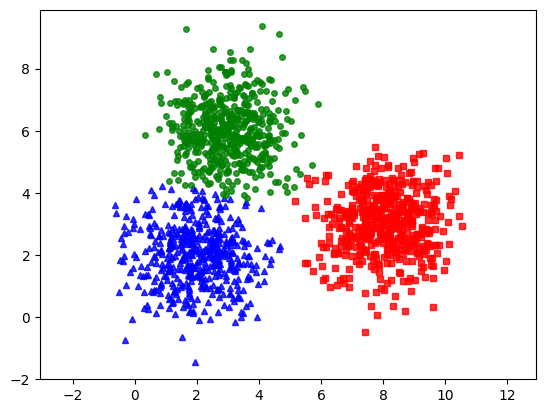

In [4]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

## Ví dụ 2

 Bắt đầu tải MNIST dataset...


Hoàn thành tải dữ liệu!: 100%|██████████| 4/4 [00:03<00:00,  1.33it/s]


 Tải dữ liệu hoàn tất!
 Kích thước dữ liệu: (1000, 784)
 Bắt đầu K-Means clustering...


Chuẩn bị hiển thị...: 100%|██████████| 3/3 [00:00<00:00, 88.66it/s]

 K-Means clustering hoàn tất!
 Thông tin cluster centers:
Type: <class 'numpy.ndarray'>
Shape: (784, 10)
 Đang tạo visualization...


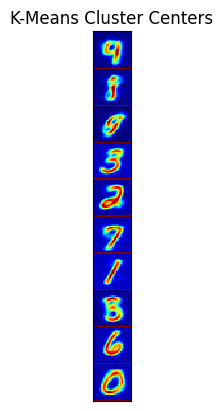

 Đã lưu ảnh cluster centers thành 'aa.png'
 Đang tạo nearest neighbors visualization...


Xử lý cluster 10/10: 100%|██████████| 10/10 [00:00<00:00, 175.70it/s]



 Đang hiển thị kết quả cuối cùng...


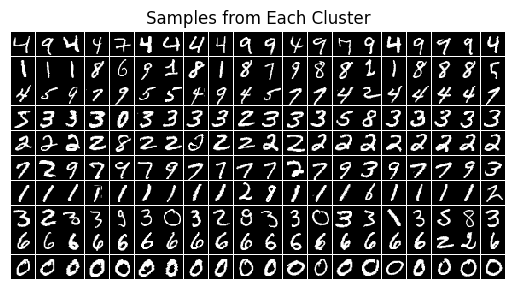

In [8]:
def display_network(A, m = -1, n = -1):
    opt_normalize = True
    opt_graycolor = True
    # Rescale
    A = A - np.average(A)
    # Compute rows & cols
    (row, col) = A.shape
    sz = int(np.ceil(np.sqrt(row)))
    buf = 1
    if m < 0 or n < 0:
        n = np.ceil(np.sqrt(col))
        m = np.ceil(col / n)

    image = np.ones(shape=(buf + m * (sz + buf), buf + n * (sz + buf)))
    if not opt_graycolor:
        image *= 0.1
    k = 0
    for i in range(int(m)):
        for j in range(int(n)):
            if k >= col:
                continue
            clim = np.max(np.abs(A[:, k]))
            if opt_normalize:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz + buf):buf + j * (sz + buf) + sz] = \
                    A[:, k].reshape(sz, sz) / clim
            else:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz + buf):buf + j * (sz + buf) + sz] = \
                A[:, k].reshape(sz, sz) / np.max(np.abs(A))
            k += 1
    return image

def display_color_network(A):
    if np.min(A) >= 0:
        A = A - np.mean(A)
    cols = np.round(np.sqrt(A.shape[1]))
    channel_size = A.shape[0] / 3
    dim = np.sqrt(channel_size)
    dimp = dim + 1
    rows = np.ceil(A.shape[1] / cols)
    B = A[0:channel_size, :]

    C = A[channel_size:2 * channel_size, :]
    D = A[2 * channel_size:3 * channel_size, :]
    B = B / np.max(np.abs(B))
    C = C / np.max(np.abs(C))
    D = D / np.max(np.abs(D))
    # Initialization of the image
    image = np.ones(shape=(dim * rows + rows - 1, dim * cols + cols - 1, 3))
    for i in range(int(rows)):
        for j in range(int(cols)):
    # This sets the patch
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 0] = B[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 1] = C[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 2] = D[:, i * cols + j].reshape(dim, dim)
    image = (image + 1) / 2
    return image

print(" Bắt đầu tải MNIST dataset...")
# Sử dụng sklearn để tải MNIST thay vì package python-mnist
with tqdm(total=4, desc="Tải MNIST") as pbar:
    pbar.set_description("Đang tải dữ liệu MNIST...")
    mnist = fetch_openml('mnist_784', version=1, parser='auto')
    pbar.update(1)
    
    pbar.set_description("Xử lý dữ liệu...")
    X_full = mnist.data.values if hasattr(mnist.data, 'values') else mnist.data
    y_full = mnist.target.values if hasattr(mnist.target, 'values') else mnist.target
    pbar.update(1)
    
    pbar.set_description("Chuẩn hóa dữ liệu...")
    # Lấy 1000 mẫu test đầu tiên và chuẩn hóa
    X = X_full[:1000] / 255.0  # Chuẩn hóa pixel từ 0-255 về 0-1
    X0 = X
    K = 10
    pbar.update(1)
    
    pbar.set_description("Hoàn thành tải dữ liệu!")
    pbar.update(1)

print(" Tải dữ liệu hoàn tất!")
print(f" Kích thước dữ liệu: {X.shape}")

print(" Bắt đầu K-Means clustering...")
# Thêm progress bar cho K-means
with tqdm(total=3, desc="K-Means") as pbar:
    pbar.set_description("Đang huấn luyện K-Means...")
    kmeans = KMeans(n_clusters=K, random_state=42, verbose=0).fit(X)
    pbar.update(1)
    
    pbar.set_description("Dự đoán nhãn...")
    pred_label = kmeans.predict(X)
    pbar.update(1)
    
    pbar.set_description("Chuẩn bị hiển thị...")
    pbar.update(1)

print(" K-Means clustering hoàn tất!")

print(" Thông tin cluster centers:")
print(f"Type: {type(kmeans.cluster_centers_.T)}")
print(f"Shape: {kmeans.cluster_centers_.T.shape}")

print(" Đang tạo visualization...")
A = display_network(kmeans.cluster_centers_.T, K, 1)
f1 = plt.imshow(A, interpolation='nearest', cmap = "jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.title("K-Means Cluster Centers")
plt.show()

# Lưu ảnh (bỏ qua scipy.misc vì đã deprecated)
plt.imsave('aa.png', A, cmap='jet')
print(" Đã lưu ảnh cluster centers thành 'aa.png'")

print(" Đang tạo nearest neighbors visualization...")
N0 = 20
X1 = np.zeros((N0*K, 784))
X2 = np.zeros((N0*K, 784))

# Thêm progress bar cho nearest neighbors
with tqdm(total=K, desc="Nearest Neighbors") as pbar:
    for k in range(K):
        pbar.set_description(f"Xử lý cluster {k+1}/{K}")
        Xk = X0[pred_label == k, :]
        if len(Xk) > 0:  # Kiểm tra cluster không rỗng
            center_k = [kmeans.cluster_centers_[k]]
            if len(Xk) >= N0:
                # Sửa lỗi: Sử dụng n_neighbors parameter thay vì positional argument
                neigh = NearestNeighbors(n_neighbors=N0).fit(Xk)
                dist, nearest_id = neigh.kneighbors(center_k, N0)
                X1[N0*k: N0*k + N0,:] = Xk[nearest_id[0], :]
                X2[N0*k: N0*k + N0,:] = Xk[:N0, :]
            else:
                # Nếu cluster có ít hơn N0 điểm, lặp lại
                n_repeat = N0 // len(Xk) + 1
                repeated_Xk = np.tile(Xk, (n_repeat, 1))[:N0]
                X1[N0*k: N0*k + N0,:] = repeated_Xk
                X2[N0*k: N0*k + N0,:] = repeated_Xk
        pbar.update(1)

print(" Đang hiển thị kết quả cuối cùng...")
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation='nearest')
plt.gray()
plt.title("Samples from Each Cluster")
plt.show()


## Bài tập tự thực hành

### Bài 1.1

 Đang tải dữ liệu MNIST...
 Đã tải 500 mẫu MNIST
 Kích thước dữ liệu: (500, 784)

 Áp dụng thuật toán K-means tự xây dựng...
 Đang chạy K-means với K=10 cụm...
 K-means hoàn tất sau 9 vòng lặp!
 Số cụm tìm được: 10

 Hiển thị cluster centers (chữ số đại diện cho mỗi cụm):
 Đã tải 500 mẫu MNIST
 Kích thước dữ liệu: (500, 784)

 Áp dụng thuật toán K-means tự xây dựng...
 Đang chạy K-means với K=10 cụm...
 K-means hoàn tất sau 9 vòng lặp!
 Số cụm tìm được: 10

 Hiển thị cluster centers (chữ số đại diện cho mỗi cụm):


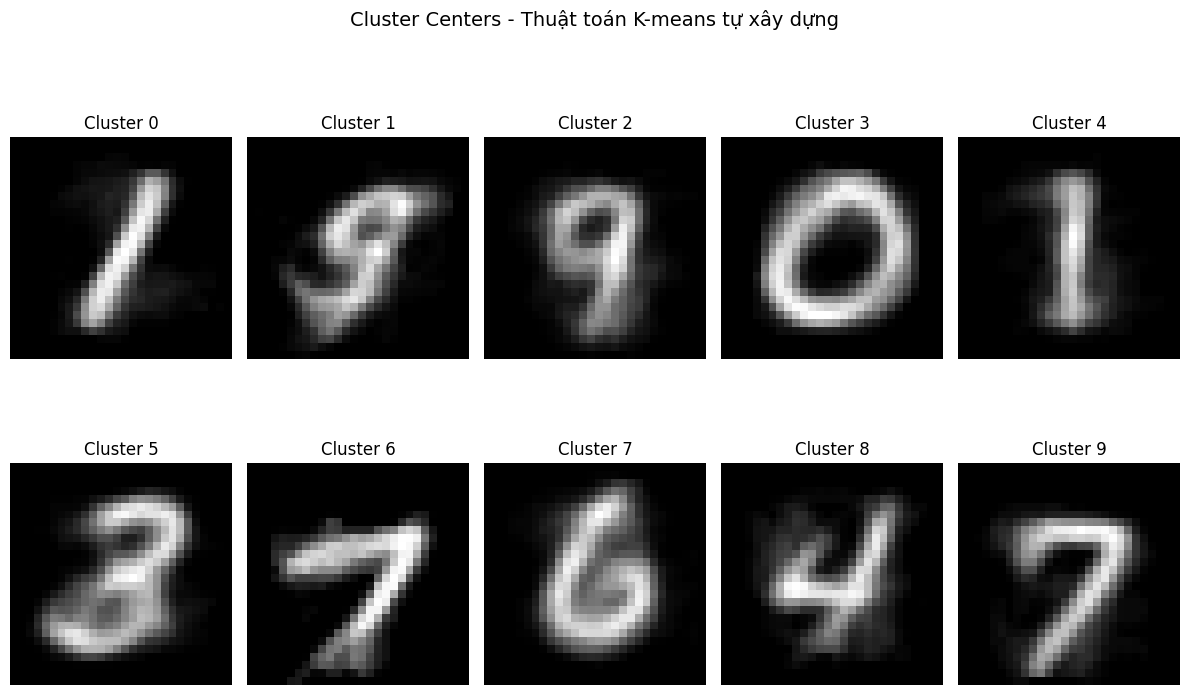


 Phân tích kết quả:
Số điểm trong mỗi cụm:
  Cluster 0:  41 điểm (  8.2%)
  Cluster 1:  54 điểm ( 10.8%)
  Cluster 2:  84 điểm ( 16.8%)
  Cluster 3:  40 điểm (  8.0%)
  Cluster 4:  56 điểm ( 11.2%)
  Cluster 5:  70 điểm ( 14.0%)
  Cluster 6:   8 điểm (  1.6%)
  Cluster 7:  82 điểm ( 16.4%)
  Cluster 8:  36 điểm (  7.2%)
  Cluster 9:  29 điểm (  5.8%)

 Thông tin thêm:
  - Tổng số điểm: 500
  - Số chiều dữ liệu: 784
  - Số vòng lặp hội tụ: 9
  - Số cụm: 10

 Hiển thị một số mẫu đại diện từ mỗi cụm:


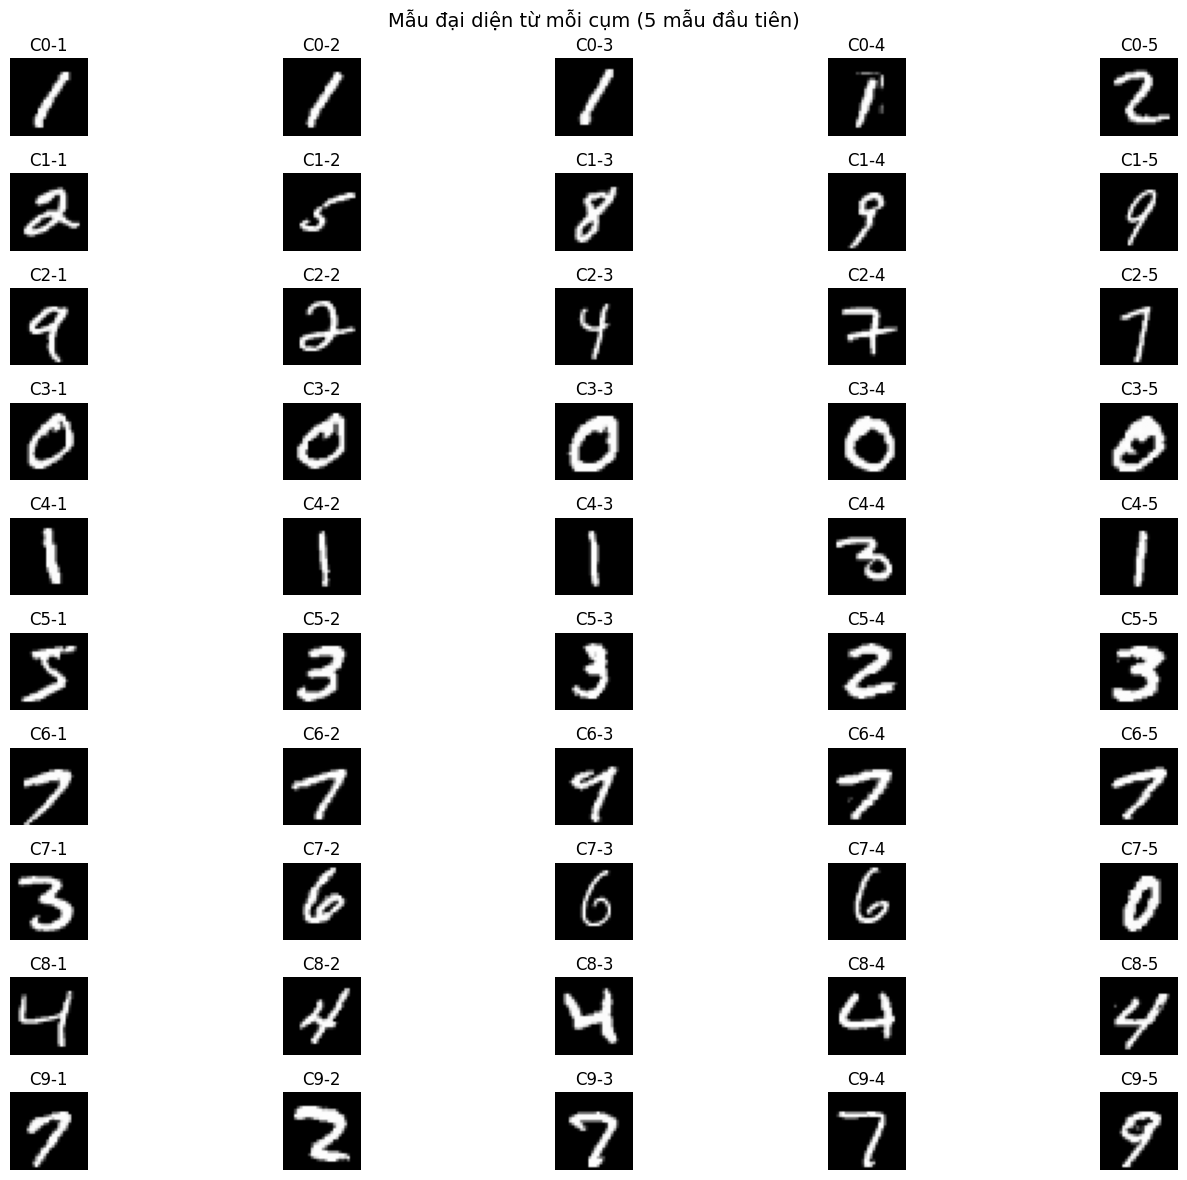

In [9]:
# Bài 1.1: Áp dụng thuật toán K-means tự xây dựng với dữ liệu MNIST

print("="*60)

# Định nghĩa lại các hàm K-means (để đảm bảo chúng có sẵn)
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

# Tải dữ liệu MNIST
print(" Đang tải dữ liệu MNIST...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_mnist = mnist.data.values if hasattr(mnist.data, 'values') else mnist.data
y_mnist = mnist.target.values if hasattr(mnist.target, 'values') else mnist.target

# Lấy 500 mẫu đầu tiên để tăng tốc độ tính toán
n_samples = 500
X_mnist_subset = X_mnist[:n_samples] / 255.0  # Chuẩn hóa về [0,1]
y_mnist_subset = y_mnist[:n_samples]

print(f" Đã tải {n_samples} mẫu MNIST")
print(f" Kích thước dữ liệu: {X_mnist_subset.shape}")

# Áp dụng thuật toán K-means tự xây dựng
print("\n Áp dụng thuật toán K-means tự xây dựng...")
K_mnist = 10  # 10 cụm cho 10 chữ số (0-9)

# Chạy thuật toán K-means tự xây dựng
print(f" Đang chạy K-means với K={K_mnist} cụm...")
(centers_custom, labels_custom, iterations) = kmeans(X_mnist_subset, K_mnist)

print(f" K-means hoàn tất sau {iterations} vòng lặp!")
print(f" Số cụm tìm được: {len(centers_custom[-1])}")

# Hiển thị centers như hình ảnh chữ số
print("\n Hiển thị cluster centers (chữ số đại diện cho mỗi cụm):")
centers_final = centers_custom[-1]

# Hiển thị centers dưới dạng hình ảnh
plt.figure(figsize=(12, 8))
for i in range(K_mnist):
    plt.subplot(2, 5, i + 1)
    # Reshape vector 784 thành hình ảnh 28x28
    center_image = centers_final[i].reshape(28, 28)
    plt.imshow(center_image, cmap='gray')
    plt.title(f'Cluster {i}')
    plt.axis('off')

plt.suptitle('Cluster Centers - Thuật toán K-means tự xây dựng', fontsize=14)
plt.tight_layout()
plt.show()

# Phân tích kết quả
print("\n Phân tích kết quả:")
labels_final = labels_custom[-1]

# Đếm số điểm trong mỗi cụm
from collections import Counter
cluster_counts = Counter(labels_final)
print("Số điểm trong mỗi cụm:")
for cluster_id in sorted(cluster_counts.keys()):
    count = cluster_counts[cluster_id]
    percentage = (count / len(labels_final)) * 100
    print(f"  Cluster {cluster_id}: {count:3d} điểm ({percentage:5.1f}%)")

# So sánh với nhãn thật (nếu có thể)
print(f"\n Thông tin thêm:")
print(f"  - Tổng số điểm: {len(X_mnist_subset)}")
print(f"  - Số chiều dữ liệu: {X_mnist_subset.shape[1]}")
print(f"  - Số vòng lặp hội tụ: {iterations}")
print(f"  - Số cụm: {K_mnist}")

# Hiển thị một số mẫu từ mỗi cụm
print("\n Hiển thị một số mẫu đại diện từ mỗi cụm:")
plt.figure(figsize=(15, 12))

for cluster_id in range(K_mnist):
    # Lấy các điểm thuộc cụm này
    cluster_indices = np.where(labels_final == cluster_id)[0]
    
    # Hiển thị 5 mẫu đầu tiên từ cụm này
    for j in range(min(5, len(cluster_indices))):
        plt.subplot(K_mnist, 5, cluster_id * 5 + j + 1)
        sample_idx = cluster_indices[j]
        sample_image = X_mnist_subset[sample_idx].reshape(28, 28)
        plt.imshow(sample_image, cmap='gray')
        plt.title(f'C{cluster_id}-{j+1}')
        plt.axis('off')

plt.suptitle('Mẫu đại diện từ mỗi cụm (5 mẫu đầu tiên)', fontsize=14)
plt.tight_layout()
plt.show()



### Bài 1.2

In [7]:
print("="*60)

import zipfile
import os
from PIL import Image
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Giải nén và tải dữ liệu
print("\n1. Giải nén và tải dữ liệu từ cats_and_dogs_filtered.zip")
zip_path = r"D:\Workspace\HUS\Machine Learning\9. Kmeans_DBScan\cats_and_dogs_filtered.zip"
extract_path = r"D:\Workspace\HUS\Machine Learning\9. Kmeans_DBScan\cats_and_dogs_data"

# Tạo thư mục nếu chưa tồn tại
os.makedirs(extract_path, exist_ok=True)

# Giải nén file zip
if not os.path.exists(os.path.join(extract_path, "cats_and_dogs_filtered")):
    print(" Đang giải nén file zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Đã giải nén thành công!")
else:
    print(" Dữ liệu đã được giải nén trước đó")

# Đường dẫn đến thư mục train
base_path = os.path.join(extract_path, "cats_and_dogs_filtered", "train")
cats_path = os.path.join(base_path, "cats")
dogs_path = os.path.join(base_path, "dogs")

print(f" Đường dẫn cats: {cats_path}")
print(f" Đường dẫn dogs: {dogs_path}")

# Kiểm tra số lượng ảnh
if os.path.exists(cats_path) and os.path.exists(dogs_path):
    num_cats = len([f for f in os.listdir(cats_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    num_dogs = len([f for f in os.listdir(dogs_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f" Số ảnh mèo: {num_cats}")
    print(f" Số ảnh chó: {num_dogs}")
    print(f" Tổng cộng: {num_cats + num_dogs} ảnh")
else:
    print(" Không tìm thấy thư mục cats và dogs!")

# 2. Tải và tiền xử lý ảnh
print(f"\n  2. Tải và tiền xử lý ảnh (resize to 64x64)")

def load_and_preprocess_images(folder_path, label, max_images=200):
    """Tải và tiền xử lý ảnh từ thư mục"""
    images = []
    labels = []
    filenames = []
    
    # Lấy danh sách file ảnh
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    image_files = image_files[:max_images]  # Giới hạn số ảnh để tăng tốc
    
    print(f"    Đang tải {len(image_files)} ảnh {label}...")
    
    with tqdm(image_files, desc=f"Loading {label}") as pbar:
        for filename in pbar:
            try:
                # Đọc ảnh
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)
                
                if img is not None:
                    # Chuyển từ BGR sang RGB
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Resize về 64x64
                    img_resized = cv2.resize(img_rgb, (64, 64))
                    # Flatten thành vector 1D
                    img_flattened = img_resized.flatten()
                    
                    images.append(img_flattened)
                    labels.append(label)
                    filenames.append(filename)
                    
            except Exception as e:
                print(f"      Lỗi khi đọc {filename}: {e}")
                continue
    
    return np.array(images), np.array(labels), filenames

# Tải ảnh (giới hạn 200 ảnh mỗi loại để tăng tốc)
max_images_per_class = 200
print(f" Giới hạn {max_images_per_class} ảnh mỗi loại để tăng tốc xử lý")

# Tải ảnh mèo
cats_images, cats_labels, cats_filenames = load_and_preprocess_images(cats_path, "cat", max_images_per_class)

# Tải ảnh chó
dogs_images, dogs_labels, dogs_filenames = load_and_preprocess_images(dogs_path, "dog", max_images_per_class)

# Kết hợp dữ liệu
X_images = np.vstack([cats_images, dogs_images])
y_true = np.hstack([cats_labels, dogs_labels])
all_filenames = cats_filenames + dogs_filenames

print(f"\n Hoàn thành tải dữ liệu:")
print(f"    Tổng số ảnh: {X_images.shape[0]}")
print(f"     Kích thước mỗi ảnh: {X_images.shape[1]} pixels (64x64x3)")
print(f"    Số ảnh mèo: {np.sum(y_true == 'cat')}")
print(f"    Số ảnh chó: {np.sum(y_true == 'dog')}")

# 3. Chuẩn hóa dữ liệu và giảm chiều
print(f"\n 3. Chuẩn hóa và giảm chiều dữ liệu")

# Chuẩn hóa dữ liệu
print("    Đang chuẩn hóa dữ liệu...")
scaler_images = StandardScaler()
X_images_scaled = scaler_images.fit_transform(X_images)

print(f"    Sau chuẩn hóa: Mean={np.mean(X_images_scaled):.6f}, Std={np.std(X_images_scaled):.6f}")

# Giảm chiều bằng PCA (để tăng tốc clustering)
print("    Đang giảm chiều bằng PCA...")
n_components = 100  # Giảm từ 12288 xuống 100 chiều
pca_images = PCA(n_components=n_components, random_state=42)
X_images_pca = pca_images.fit_transform(X_images_scaled)

explained_variance = sum(pca_images.explained_variance_ratio_)
print(f"    Giảm chiều: {X_images_scaled.shape[1]} → {X_images_pca.shape[1]} chiều")
print(f"    Variance preserved: {explained_variance:.2%}")

# 4. Áp dụng K-means với K=2
print(f"\n 4. Áp dụng K-means với K=2 (chó vs mèo)")

# Sử dụng custom K-means function từ cell trước
print("    Sử dụng custom K-means implementation...")

# Khởi tạo centers
np.random.seed(42)
K_animals = 2
centers_animals = kmeans_init_centers(X_images_pca, K_animals)

print(f"    Đã khởi tạo {K_animals} centers")
print(f"    Bắt đầu training K-means...")

# Training K-means
max_iterations = 50
centers_history = [centers_animals.copy()]

with tqdm(range(max_iterations), desc="K-means training") as pbar:
    for iteration in pbar:
        # Assign labels
        labels_animals = kmeans_assign_labels(X_images_pca, centers_animals)
        
        # Update centers
        new_centers = kmeans_update_centers(X_images_pca, labels_animals, K_animals)
        
        # Kiểm tra convergence
        center_shift = np.mean([np.linalg.norm(new_centers[i] - centers_animals[i]) 
                               for i in range(K_animals)])
        
        centers_animals = new_centers
        centers_history.append(centers_animals.copy())
        
        pbar.set_postfix({'Center_shift': f'{center_shift:.6f}'})
        
        if center_shift < 1e-4:
            print(f"\n   Converged sau {iteration + 1} iterations")
            break

final_labels_animals = kmeans_assign_labels(X_images_pca, centers_animals)

print(f"\n 5. Kết quả clustering:")
print(f"    Số iterations: {len(centers_history)}")
print(f"    Cluster 0: {np.sum(final_labels_animals == 0)} ảnh")
print(f"    Cluster 1: {np.sum(final_labels_animals == 1)} ảnh")


1. Giải nén và tải dữ liệu từ cats_and_dogs_filtered.zip
 Dữ liệu đã được giải nén trước đó
 Đường dẫn cats: D:\Workspace\HUS\Machine Learning\9. Kmeans_DBScan\cats_and_dogs_data\cats_and_dogs_filtered\train\cats
 Đường dẫn dogs: D:\Workspace\HUS\Machine Learning\9. Kmeans_DBScan\cats_and_dogs_data\cats_and_dogs_filtered\train\dogs
 Số ảnh mèo: 1000
 Số ảnh chó: 1000
 Tổng cộng: 2000 ảnh

  2. Tải và tiền xử lý ảnh (resize to 64x64)
 Giới hạn 200 ảnh mỗi loại để tăng tốc xử lý
    Đang tải 200 ảnh cat...


Loading cat: 100%|██████████| 200/200 [00:00<00:00, 1133.00it/s]


    Đang tải 200 ảnh dog...


Loading dog: 100%|██████████| 200/200 [00:00<00:00, 1118.68it/s]




 Hoàn thành tải dữ liệu:
    Tổng số ảnh: 400
     Kích thước mỗi ảnh: 12288 pixels (64x64x3)
    Số ảnh mèo: 200
    Số ảnh chó: 200

 3. Chuẩn hóa và giảm chiều dữ liệu
    Đang chuẩn hóa dữ liệu...
    Sau chuẩn hóa: Mean=0.000000, Std=1.000000
    Đang giảm chiều bằng PCA...
    Sau chuẩn hóa: Mean=0.000000, Std=1.000000
    Đang giảm chiều bằng PCA...
    Giảm chiều: 12288 → 100 chiều
    Variance preserved: 86.86%

 4. Áp dụng K-means với K=2 (chó vs mèo)
    Sử dụng custom K-means implementation...
    Đã khởi tạo 2 centers
    Bắt đầu training K-means...
    Giảm chiều: 12288 → 100 chiều
    Variance preserved: 86.86%

 4. Áp dụng K-means với K=2 (chó vs mèo)
    Sử dụng custom K-means implementation...
    Đã khởi tạo 2 centers
    Bắt đầu training K-means...


K-means training:  14%|█▍        | 7/50 [00:00<00:00, 1227.12it/s, Center_shift=0.000000]


   Converged sau 8 iterations

 5. Kết quả clustering:
    Số iterations: 9
    Cluster 0: 203 ảnh
    Cluster 1: 197 ảnh



 6. Phân tích và đánh giá kết quả clustering:

    Composition của các cluster:
      Cluster 0: 203 ảnh 🐱
         🐱 Mèo: 113 (55.7%)
         🐶 Chó: 90 (44.3%)
         🏆 Majority: cat
      Cluster 1: 197 ảnh 🐶
         🐱 Mèo: 87 (44.2%)
         🐶 Chó: 110 (55.8%)
         🏆 Majority: dog

    Clustering Accuracy: 55.75%

    Confusion Matrix:
        Predicted:
         cat   dog
   cat   113    87
   dog    90   110

    Các metrics (với 'cat' là positive class):
      Accuracy:  0.5575
      Precision: 0.5567
      Recall:    0.5650
      F1-Score:  0.5608

 7. Visualization kết quả:


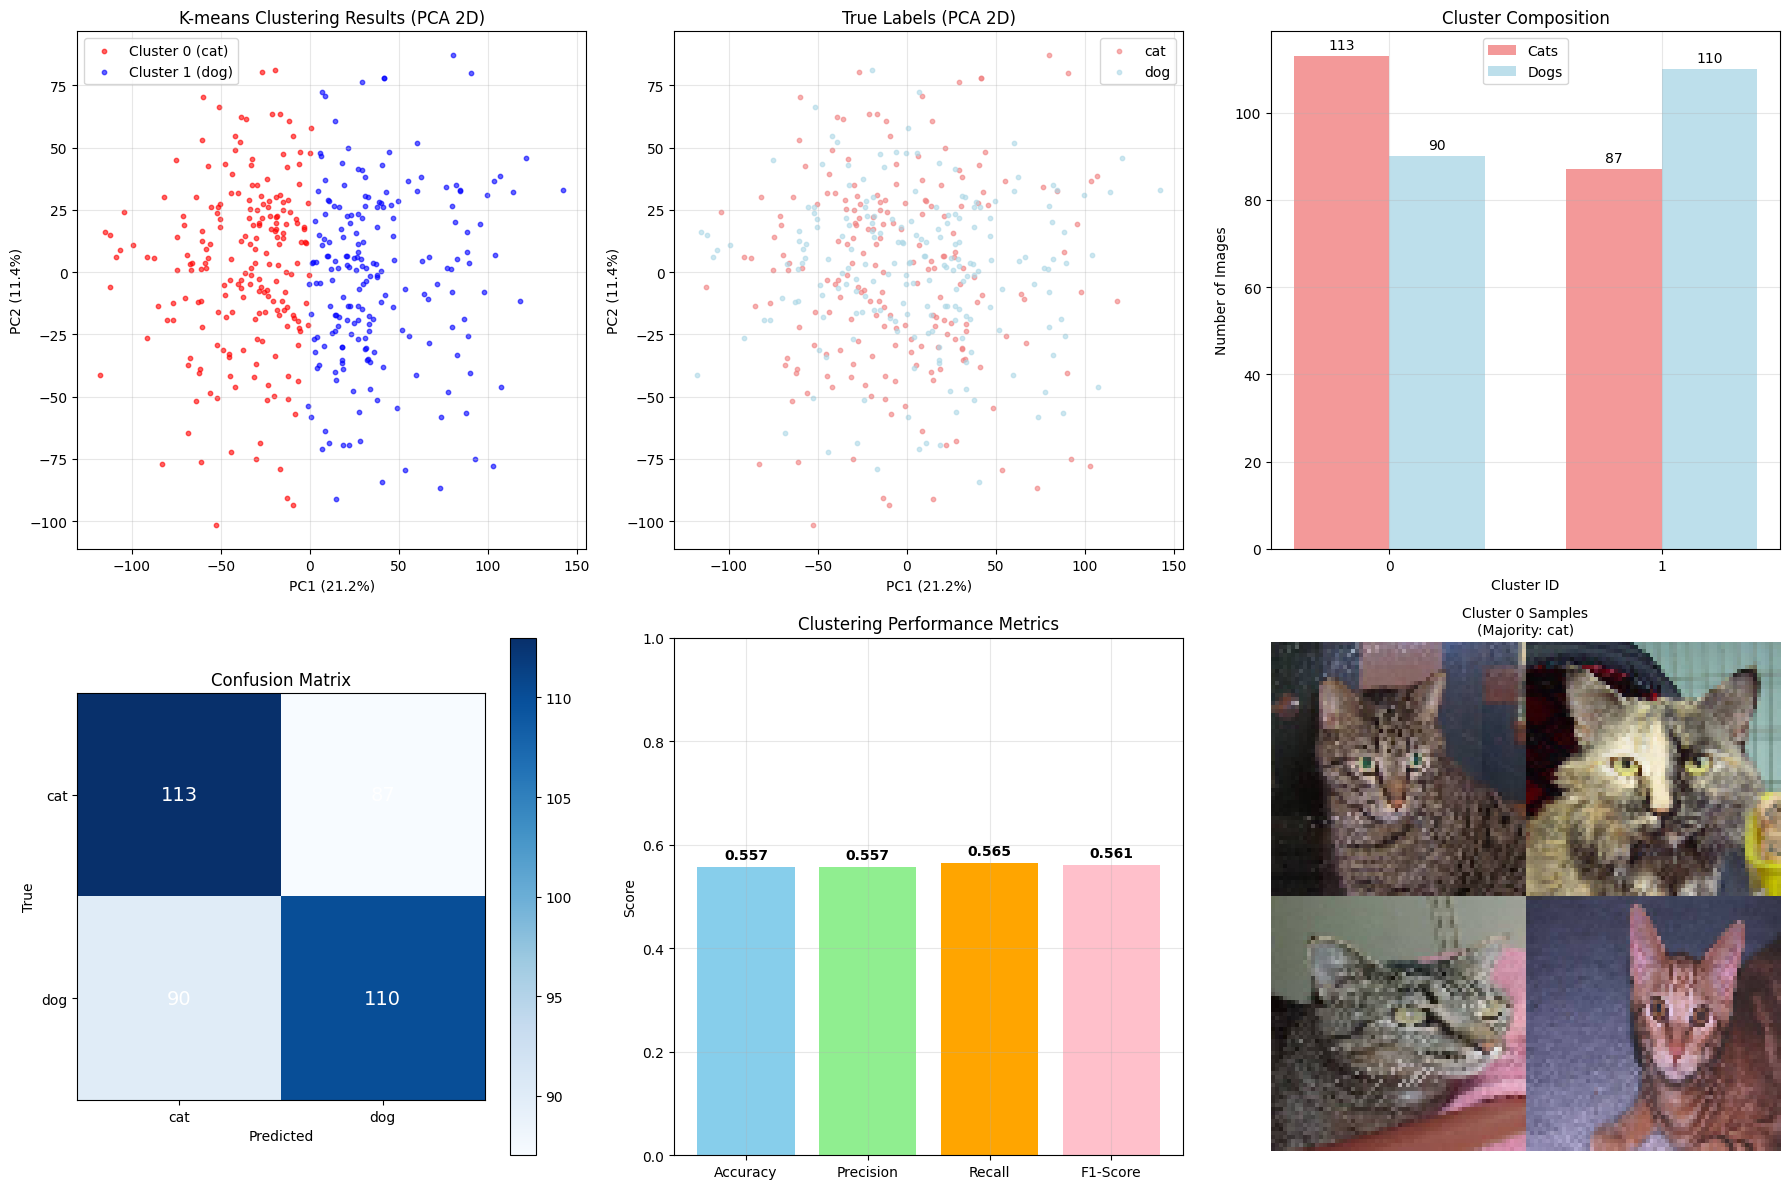


 8. KẾT LUẬN BÀI 1.2:
 Tổng kết clustering ảnh chó-mèo:
     Số ảnh đã clustering: 400
    K-means với K=2
    PCA giảm chiều: 12288 → 100
    Clustering Accuracy: 55.75%
    KHÓ KHĂN. K-means gặp khó khăn trong việc phân biệt chó-mèo

 Nhận xét:
   • K-means với ảnh raw có thể không tối ưu do:
     - Pixel-wise distance không phản ánh semantic similarity
     - Cần feature extraction tốt hơn (CNN features)
     - Lighting, pose, background ảnh hưởng nhiều
   • PCA giúp giảm noise nhưng có thể mất thông tin quan trọng
   • Kết quả 55.8% cho thấy có thể phân biệt một phần


In [8]:
# 6. Phân tích và đánh giá kết quả clustering
print(f"\n 6. Phân tích và đánh giá kết quả clustering:")

# Tạo mapping để hiểu cluster nào tương ứng với chó/mèo
def analyze_clusters(y_true, y_pred):
    """Phân tích composition của các cluster"""
    results = {}
    for cluster_id in np.unique(y_pred):
        cluster_mask = y_pred == cluster_id
        cluster_true_labels = y_true[cluster_mask]
        
        cat_count = np.sum(cluster_true_labels == 'cat')
        dog_count = np.sum(cluster_true_labels == 'dog')
        total_count = len(cluster_true_labels)
        
        cat_pct = (cat_count / total_count) * 100
        dog_pct = (dog_count / total_count) * 100
        
        results[cluster_id] = {
            'total': total_count,
            'cats': cat_count,
            'dogs': dog_count,
            'cat_pct': cat_pct,
            'dog_pct': dog_pct,
            'majority': 'cat' if cat_count > dog_count else 'dog'
        }
    
    return results

cluster_analysis = analyze_clusters(y_true, final_labels_animals)

print("\n    Composition của các cluster:")
for cluster_id, info in cluster_analysis.items():
    majority_emoji = "🐱" if info['majority'] == 'cat' else "🐶"
    print(f"      Cluster {cluster_id}: {info['total']} ảnh {majority_emoji}")
    print(f"         🐱 Mèo: {info['cats']} ({info['cat_pct']:.1f}%)")
    print(f"         🐶 Chó: {info['dogs']} ({info['dog_pct']:.1f}%)")
    print(f"         🏆 Majority: {info['majority']}")

# Tính accuracy dựa trên majority voting
def calculate_clustering_accuracy(y_true, y_pred, cluster_analysis):
    """Tính accuracy của clustering bằng majority voting"""
    correct = 0
    total = len(y_true)
    
    for i in range(total):
        cluster_id = y_pred[i]
        predicted_label = cluster_analysis[cluster_id]['majority']
        true_label = y_true[i]
        
        if predicted_label == true_label:
            correct += 1
    
    accuracy = (correct / total) * 100
    return accuracy

clustering_accuracy = calculate_clustering_accuracy(y_true, final_labels_animals, cluster_analysis)
print(f"\n    Clustering Accuracy: {clustering_accuracy:.2f}%")

# Tính confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

# Tạo predicted labels dựa trên majority
y_pred_majority = []
for label in final_labels_animals:
    y_pred_majority.append(cluster_analysis[label]['majority'])

y_pred_majority = np.array(y_pred_majority)

print(f"\n    Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred_majority, labels=['cat', 'dog'])
print(f"        Predicted:")
print(f"         cat   dog")
print(f"   cat   {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"   dog   {cm[1,0]:3d}   {cm[1,1]:3d}")

# Tính các metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_majority)
precision = precision_score(y_true, y_pred_majority, pos_label='cat')
recall = recall_score(y_true, y_pred_majority, pos_label='cat')
f1 = f1_score(y_true, y_pred_majority, pos_label='cat')

print(f"\n    Các metrics (với 'cat' là positive class):")
print(f"      Accuracy:  {accuracy:.4f}")
print(f"      Precision: {precision:.4f}")
print(f"      Recall:    {recall:.4f}")
print(f"      F1-Score:  {f1:.4f}")

# 7. Visualization kết quả
print(f"\n 7. Visualization kết quả:")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: PCA visualization của clusters
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_images_pca)

colors_pred = ['red', 'blue']
colors_true = ['lightcoral', 'lightblue']

# Predicted clusters
for cluster_id in range(K_animals):
    mask = final_labels_animals == cluster_id
    majority = cluster_analysis[cluster_id]['majority']
    label = f"Cluster {cluster_id} ({majority})"
    axes[0, 0].scatter(X_2d[mask, 0], X_2d[mask, 1], 
                      c=colors_pred[cluster_id], alpha=0.6, s=10, label=label)

axes[0, 0].set_title('K-means Clustering Results (PCA 2D)', fontsize=12)
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: True labels
for i, animal in enumerate(['cat', 'dog']):
    mask = y_true == animal
    axes[0, 1].scatter(X_2d[mask, 0], X_2d[mask, 1], 
                      c=colors_true[i], alpha=0.6, s=10, label=f'{animal}')

axes[0, 1].set_title('True Labels (PCA 2D)', fontsize=12)
axes[0, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cluster composition bar chart
cluster_ids = list(cluster_analysis.keys())
cat_counts = [cluster_analysis[cid]['cats'] for cid in cluster_ids]
dog_counts = [cluster_analysis[cid]['dogs'] for cid in cluster_ids]

x = np.arange(len(cluster_ids))
width = 0.35

bars1 = axes[0, 2].bar(x - width/2, cat_counts, width, label='Cats', color='lightcoral', alpha=0.8)
bars2 = axes[0, 2].bar(x + width/2, dog_counts, width, label='Dogs', color='lightblue', alpha=0.8)

axes[0, 2].set_title('Cluster Composition', fontsize=12)
axes[0, 2].set_xlabel('Cluster ID')
axes[0, 2].set_ylabel('Number of Images')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(cluster_ids)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{int(height)}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{int(height)}', ha='center', va='bottom')

# Plot 4: Confusion Matrix heatmap
im = axes[1, 0].imshow(cm, cmap='Blues', interpolation='nearest')
axes[1, 0].set_title('Confusion Matrix', fontsize=12)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['cat', 'dog'])
axes[1, 0].set_yticklabels(['cat', 'dog'])

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center', 
                       color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.colorbar(im, ax=axes[1, 0])

# Plot 5: Accuracy comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

bars = axes[1, 1].bar(metrics_names, metrics_values, color=['skyblue', 'lightgreen', 'orange', 'pink'])
axes[1, 1].set_title('Clustering Performance Metrics', fontsize=12)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, metrics_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Sample images từ mỗi cluster
def show_sample_images_from_clusters(X_original, labels, cluster_analysis, filenames, axes):
    """Hiển thị sample images từ mỗi cluster"""
    
    for cluster_id in range(K_animals):
        cluster_mask = labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        # Lấy 4 ảnh đầu tiên từ cluster
        sample_indices = cluster_indices[:4] if len(cluster_indices) >= 4 else cluster_indices
        
        # Tạo grid 2x2 cho mỗi cluster
        grid = np.zeros((128, 128, 3), dtype=np.uint8)
        
        for i, idx in enumerate(sample_indices):
            # Reshape ảnh từ vector về ảnh 64x64x3
            img = X_original[idx].reshape(64, 64, 3)
            
            # Đặt vào grid
            row = i // 2
            col = i % 2
            grid[row*64:(row+1)*64, col*64:(col+1)*64, :] = img
        
        # Hiển thị grid
        if cluster_id == 0:
            axes[1, 2].imshow(grid)
            majority = cluster_analysis[cluster_id]['majority']
            axes[1, 2].set_title(f'Cluster {cluster_id} Samples\n(Majority: {majority})', fontsize=10)
            axes[1, 2].axis('off')

# Hiển thị sample images (chỉ cluster 0 do giới hạn subplot)
show_sample_images_from_clusters(X_images, final_labels_animals, cluster_analysis, all_filenames, axes)

plt.tight_layout()
plt.show()

# 8. Kết luận
print(f"\n 8. KẾT LUẬN BÀI 1.2:")
print("="*50)
print(f" Tổng kết clustering ảnh chó-mèo:")
print(f"     Số ảnh đã clustering: {len(y_true)}")
print(f"    K-means với K=2")
print(f"    PCA giảm chiều: {X_images.shape[1]} → {X_images_pca.shape[1]}")
print(f"    Clustering Accuracy: {clustering_accuracy:.2f}%")

if clustering_accuracy > 70:
    conclusion = " THÀNH CÔNG! K-means đã phân cụm khá tốt"
elif clustering_accuracy > 60:
    conclusion = "  TRUNG BÌNH. K-means phân cụm có hiệu quả hạn chế"
else:
    conclusion = " KHÓ KHĂN. K-means gặp khó khăn trong việc phân biệt chó-mèo"

print(f"   {conclusion}")

print(f"\n Nhận xét:")
print(f"   • K-means với ảnh raw có thể không tối ưu do:")
print(f"     - Pixel-wise distance không phản ánh semantic similarity")
print(f"     - Cần feature extraction tốt hơn (CNN features)")
print(f"     - Lighting, pose, background ảnh hưởng nhiều")
print(f"   • PCA giúp giảm noise nhưng có thể mất thông tin quan trọng")
print(f"   • Kết quả {clustering_accuracy:.1f}% cho thấy có thể phân biệt một phần")


# 2. Phần mô hình DBScan

## Ví dụ 2.1

In [10]:
class DBSCAN(object):

    def __init__(self,x,epsilon,minpts):
        # The number of input dataset
        self.n = len(x)
        # Euclidean distance
        p, q = np.meshgrid(np.arange(self.n), np.arange(self.n))
        self.dist = np.sqrt(np.sum(((x[p] - x[q])**2),2))
        # label as visited points and noise
        self.visited = np.full((self.n), False)
        self.noise = np.full((self.n),False)
        # DBSCAN Parameters
        self.epsilon = epsilon
        self.minpts = minpts
        # Cluseter
        self.idx = np.full((self.n),0)
        self.C = 0
        self.input = x

    def run(self):
        # Clustering
        for i in range(len(self.input)):
            if self.visited[i] == False:
                self.visited[i] = True
                self.neighbors = self.regionQuery(i)
                if len(self.neighbors) >= self.minpts:
                    self.C += 1
                    self.expandCluster(i)
                else : self.noise[i] = True
        return self.idx,self.noise

    def regionQuery(self, i):
        g = self.dist[i,:] < self.epsilon
        Neighbors = np.where(g)[0].tolist()
        return Neighbors

    def expandCluster(self, i):
        self.idx[i] = self.C
        k = 0
       
        while True:
            if len(self.neighbors) <= k:return
            j = self.neighbors[k]
            if self.visited[j] != True:
                self.visited[j] = True

                self.neighbors2 = self.regionQuery(j)
                v = [self.neighbors2[i] for i in np.where(self.idx[self.neighbors2]==0)[0]]

                if len(self.neighbors2) >=  self.minpts:
                    self.neighbors = self.neighbors+v

            if self.idx[j] == 0 : self.idx[j] = self.C
            k += 1

    def sort(self):
        
        cnum = np.max(self.idx)
        self.cluster = []
        self.noise = []
        for i in range(cnum):
           
            k = np.where(self.idx == (i+1))[0].tolist()
            self.cluster.append([self.input[k,:]])
       
        self.noise = self.input[np.where(self.idx == 0)[0].tolist(),:]
        return self.cluster, self.noise

    def plot(self):
        
        self.sort()
        fig,ax = plt.subplots()
        
        for idx,group in enumerate(self.cluster):
        
            ax.plot(group[0][:,0],
                    group[0][:,1],
                    marker='o',
                    linestyle='',
                    label='Cluster {}'.format(idx))

        # Sửa lỗi: Kiểm tra kích thước array thay vì None
        if self.noise.size > 0:
            ax.plot(self.noise[:,0],
                    self.noise[:,1],
                    marker='x',
                    linestyle='',
                    label='noise')

        ax.legend(fontsize=10, loc='upper left')
        plt.title('Scatter Plot of Clustering result', fontsize=15)
        plt.xlabel('X', fontsize=14)
        plt.ylabel('Y', fontsize=14)
        plt.show()

 Ví dụ: Áp dụng DBSCAN trên dữ liệu input.csv
 Đang thực hiện DBSCAN clustering...
 Hoàn thành clustering!
 Tìm được 2 cụm
 Số điểm nhiễu: 0
 Hiển thị kết quả:


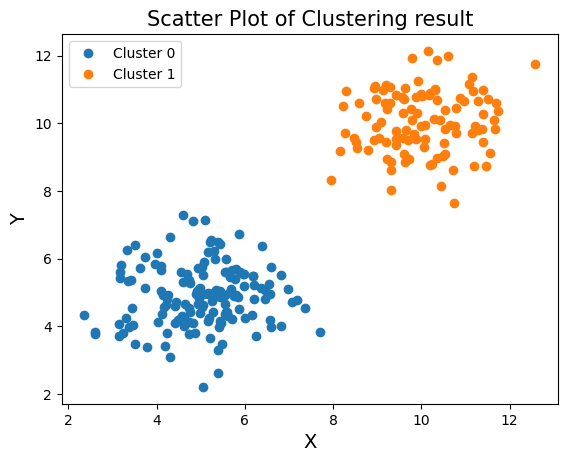

In [11]:
# Load data
df = pd.read_csv('D:\\Workspace\\HUS\\Machine Learning\\9. Kmeans_DBScan\\input.csv')
x = np.zeros([len(df), 2], float )
x[:, 0] = np.array(df['x1'], float)
x[:, 1] = np.array(df['x2'], float)

print(" Ví dụ: Áp dụng DBSCAN trên dữ liệu input.csv")
print("="*60)

# INIT DBSCAN
dbscan = DBSCAN(x,1.5,4)

# CLUSTERING
print(" Đang thực hiện DBSCAN clustering...")
idx,noise = dbscan.run()
print(f" Hoàn thành clustering!")

# SORTING
g_cluster,n_cluster = dbscan.sort()
print(f" Tìm được {len(g_cluster)} cụm")
print(f" Số điểm nhiễu: {len(n_cluster)}")

# Visualization
print(" Hiển thị kết quả:")
dbscan.plot()

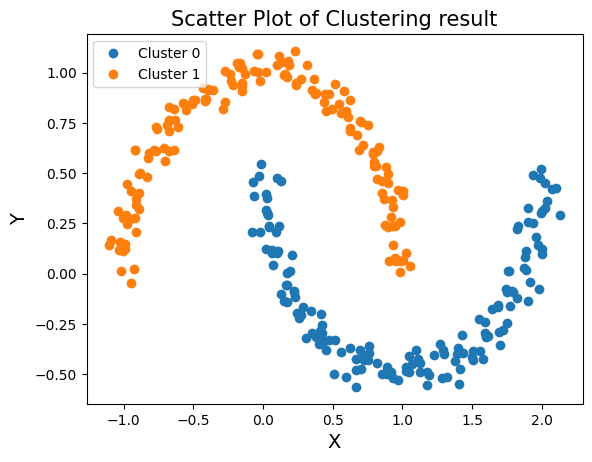

In [ ]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# INIT DBSCAN
dbscan = DBSCAN(X, 0.3, 5)
# CLUSTERING
idx,noise = dbscan.run()
# SORTING
g_cluster,n_cluster = dbscan.sort()
# Visualization
dbscan.plot()

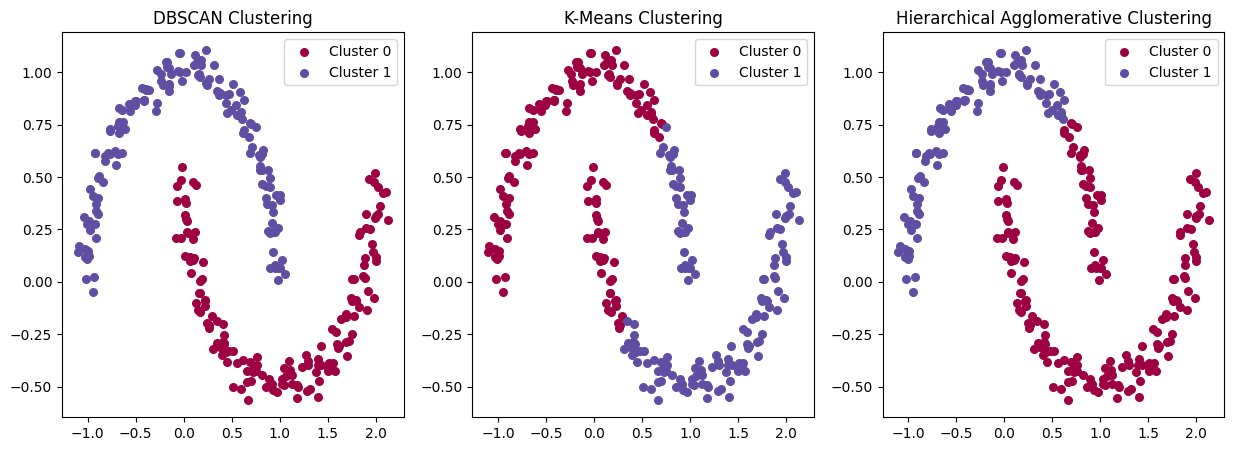

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons

# Generate synthetic data (you can replace this with your own data)
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Apply Hierarchical Agglomerative Clustering (HAC)
hac = AgglomerativeClustering(n_clusters=2)
hac_labels = hac.fit_predict(X)

# Plot the results for DBSCAN
plt.figure(figsize=(15, 5))

plt.subplot(131)
unique_labels_dbscan = np.unique(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_dbscan)))

for label, color in zip(unique_labels_dbscan, colors):
    if label == -1:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color='gray', s=10, label='Noise')
    else:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('DBSCAN Clustering')
plt.legend()

# Plot the results for K-Means
plt.subplot(132)
unique_labels_kmeans = np.unique(kmeans_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_kmeans)))

for label, color in zip(unique_labels_kmeans, colors):
    plt.scatter(X[kmeans_labels == label][:, 0], X[kmeans_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('K-Means Clustering')
plt.legend()

# Plot the results for HAC
plt.subplot(133)
unique_labels_hac = np.unique(hac_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_hac)))

for label, color in zip(unique_labels_hac, colors):
    plt.scatter(X[hac_labels == label][:, 0], X[hac_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('Hierarchical Agglomerative Clustering')
plt.legend()

plt.show()

## Bài tập 2.1

 Sử dụng dữ liệu từ input.csv...
 Kích thước dữ liệu: (256, 2)
 Dữ liệu có 256 điểm với 2 chiều (x1, x2)

 1. Kết quả DBSCAN (từ ví dụ trước):
    Số cụm tìm được: 2
    Số điểm nhiễu: 0
    Tham số: epsilon=1.5, min_samples=4

 2. Thực hiện K-means clustering:
 Thử nghiệm với các giá trị K khác nhau:
   K=2: WCSS = 467.55
   K=3: WCSS = 360.63
   K=4: WCSS = 290.86
   K=5: WCSS = 239.10

 Chọn K=2 để so sánh với DBSCAN
 WCSS cho K=2: 467.55

 3. So sánh trực quan giữa DBSCAN và K-means:


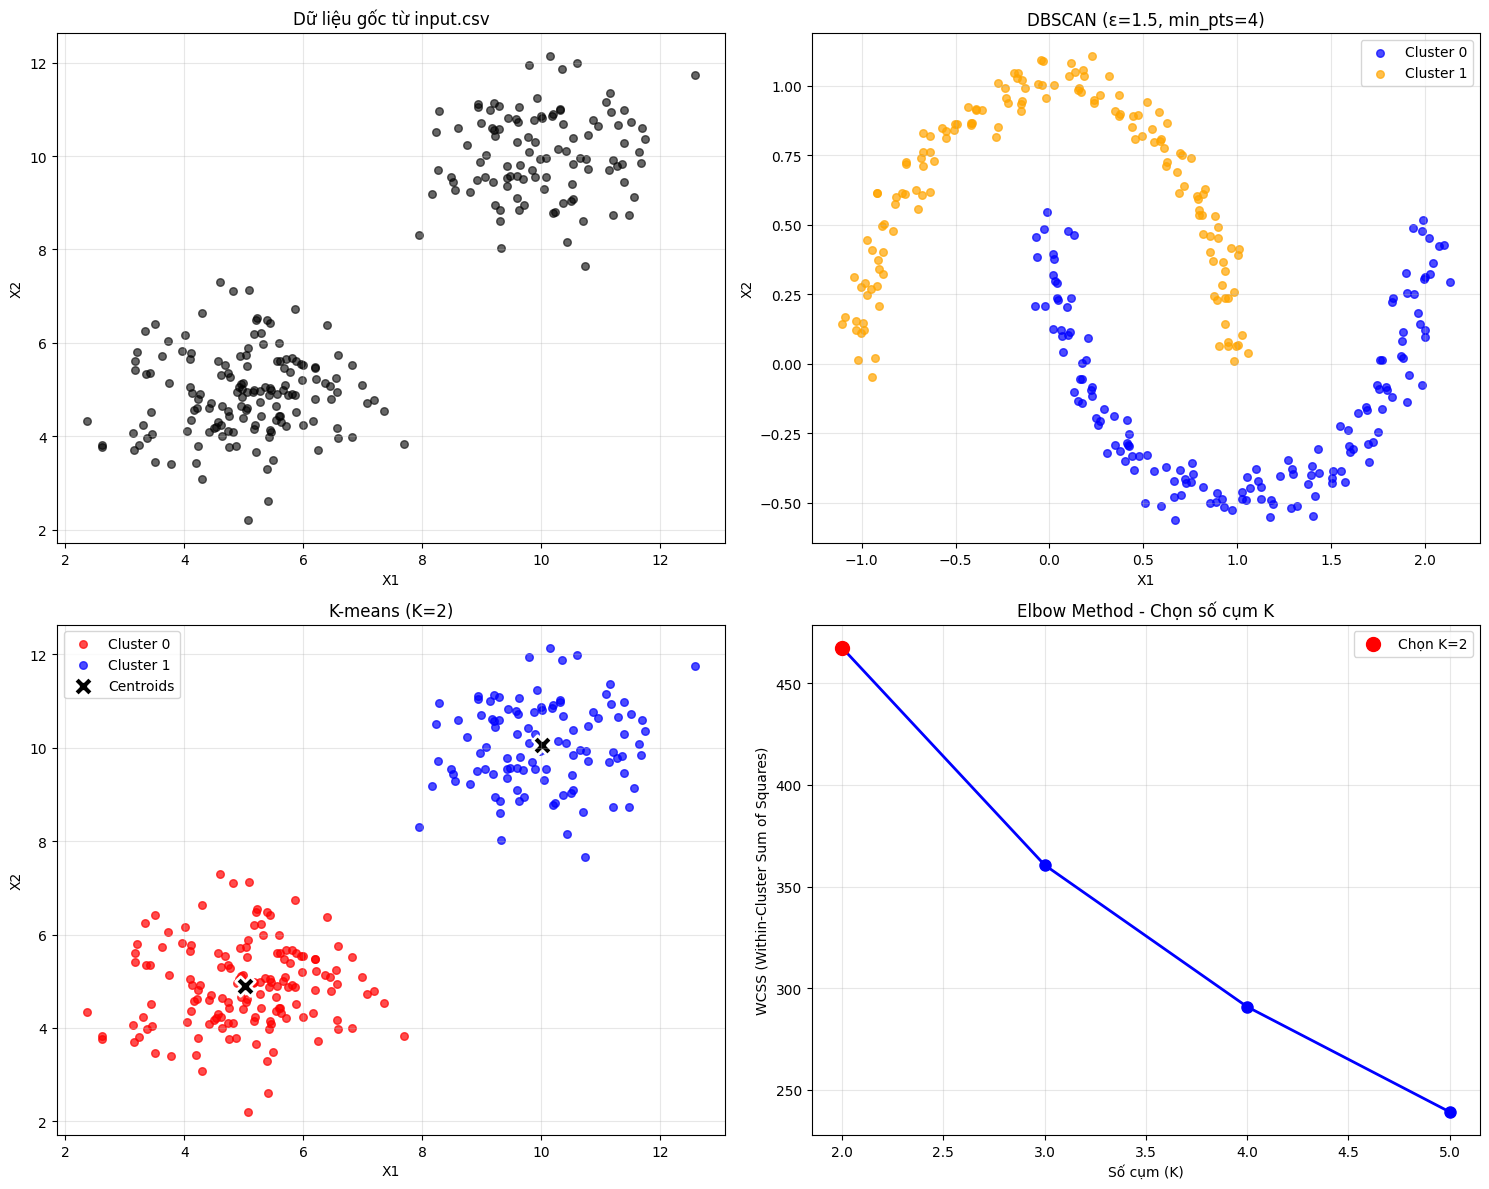


 4. Phân tích so sánh:
 DBSCAN:
    Ưu điểm:
      - Tự động xác định số cụm
      - Phát hiện được điểm nhiễu (outliers)
      - Phù hợp với cụm có hình dạng bất kỳ
     Kết quả: 2 cụm, 0 điểm nhiễu

 K-means:
    Ưu điểm:
      - Đơn giản, nhanh chóng
      - Phân loại tất cả các điểm (không có nhiễu)
      - Phù hợp với cụm hình tròn, kích thước đồng đều
     Kết quả: 2 cụm, 0 điểm nhiễu

 5. Kết luận:
   Với dataset này:
      - DBSCAN tìm được 2 cụm tự nhiên
      - K-means với K=2 cho kết quả tương tự
      - DBSCAN linh hoạt hơn trong việc phát hiện cụm bất thường
      - K-means nhanh hơn và đơn giản hơn


In [ ]:
print("="*70)

# Sử dụng lại dữ liệu từ Ví dụ 2.1 (đã được load trong cell trước)
print(" Sử dụng dữ liệu từ input.csv...")
print(f" Kích thước dữ liệu: {x.shape}")
print(f" Dữ liệu có {len(x)} điểm với 2 chiều (x1, x2)")

# 1. Thực hiện DBSCAN (đã có từ ví dụ trước)
print("\n 1. Kết quả DBSCAN (từ ví dụ trước):")
print(f"    Số cụm tìm được: {len(g_cluster)}")
print(f"    Số điểm nhiễu: {len(n_cluster)}")
print(f"    Tham số: epsilon={1.5}, min_samples={4}")

# 2. Thực hiện K-means clustering
print("\n 2. Thực hiện K-means clustering:")

# Thử với số cụm khác nhau để tìm số cụm tối ưu
k_values = [2, 3, 4, 5]
kmeans_results = {}

print(" Thử nghiệm với các giá trị K khác nhau:")
for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans_model.fit_predict(x)
    
    # Tính Within-Cluster Sum of Squares (WCSS) - Elbow method
    wcss = kmeans_model.inertia_
    kmeans_results[k] = {
        'model': kmeans_model,
        'labels': kmeans_labels,
        'wcss': wcss,
        'centers': kmeans_model.cluster_centers_
    }
    print(f"   K={k}: WCSS = {wcss:.2f}")

# Chọn K=2 dựa trên kết quả DBSCAN (tìm được 2 cụm)
optimal_k = 2
kmeans_optimal = kmeans_results[optimal_k]

print(f"\n Chọn K={optimal_k} để so sánh với DBSCAN")
print(f" WCSS cho K={optimal_k}: {kmeans_optimal['wcss']:.2f}")

# 3. So sánh trực quan
print("\n 3. So sánh trực quan giữa DBSCAN và K-means:")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Dữ liệu gốc
axes[0, 0].scatter(x[:, 0], x[:, 1], c='black', alpha=0.6, s=30)
axes[0, 0].set_title('Dữ liệu gốc từ input.csv', fontsize=12)
axes[0, 0].set_xlabel('X1')
axes[0, 0].set_ylabel('X2')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Kết quả DBSCAN
colors_dbscan = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
for i, cluster in enumerate(g_cluster):
    cluster_data = cluster[0]
    axes[0, 1].scatter(cluster_data[:, 0], cluster_data[:, 1], 
                      c=colors_dbscan[i % len(colors_dbscan)], 
                      label=f'Cluster {i}', s=30, alpha=0.7)

if len(n_cluster) > 0:
    axes[0, 1].scatter(n_cluster[:, 0], n_cluster[:, 1], 
                      c='gray', marker='x', label='Noise', s=50)

axes[0, 1].set_title(f'DBSCAN (ε={1.5}, min_pts={4})', fontsize=12)
axes[0, 1].set_xlabel('X1')
axes[0, 1].set_ylabel('X2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Kết quả K-means
kmeans_labels = kmeans_optimal['labels']
colors_kmeans = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
for i in range(optimal_k):
    cluster_mask = kmeans_labels == i
    axes[1, 0].scatter(x[cluster_mask, 0], x[cluster_mask, 1], 
                      c=colors_kmeans[i % len(colors_kmeans)], 
                      label=f'Cluster {i}', s=30, alpha=0.7)

# Hiển thị centroids
centers = kmeans_optimal['centers']
axes[1, 0].scatter(centers[:, 0], centers[:, 1], 
                  c='black', marker='X', s=200, 
                  label='Centroids', edgecolors='white', linewidth=2)

axes[1, 0].set_title(f'K-means (K={optimal_k})', fontsize=12)
axes[1, 0].set_xlabel('X1')
axes[1, 0].set_ylabel('X2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Elbow method để chọn K
wcss_values = [kmeans_results[k]['wcss'] for k in k_values]
axes[1, 1].plot(k_values, wcss_values, 'bo-', linewidth=2, markersize=8)
axes[1, 1].set_title('Elbow Method - Chọn số cụm K', fontsize=12)
axes[1, 1].set_xlabel('Số cụm (K)')
axes[1, 1].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[1, 1].grid(True, alpha=0.3)

# Đánh dấu điểm optimal
axes[1, 1].scatter([optimal_k], [kmeans_optimal['wcss']], 
                  c='red', s=100, marker='o', 
                  label=f'Chọn K={optimal_k}', zorder=5)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 4. Phân tích so sánh
print("\n 4. Phân tích so sánh:")
print("="*50)

print(" DBSCAN:")
print(f"    Ưu điểm:")
print(f"      - Tự động xác định số cụm")
print(f"      - Phát hiện được điểm nhiễu (outliers)")
print(f"      - Phù hợp với cụm có hình dạng bất kỳ")
print(f"     Kết quả: {len(g_cluster)} cụm, {len(n_cluster)} điểm nhiễu")

print(f"\n K-means:")
print(f"    Ưu điểm:")
print(f"      - Đơn giản, nhanh chóng")
print(f"      - Phân loại tất cả các điểm (không có nhiễu)")
print(f"      - Phù hợp với cụm hình tròn, kích thước đồng đều")
print(f"     Kết quả: {optimal_k} cụm, 0 điểm nhiễu")

print(f"\n 5. Kết luận:")
print(f"   Với dataset này:")
print(f"      - DBSCAN tìm được {len(g_cluster)} cụm tự nhiên")
print(f"      - K-means với K={optimal_k} cho kết quả tương tự")
print(f"      - DBSCAN linh hoạt hơn trong việc phát hiện cụm bất thường")
print(f"      - K-means nhanh hơn và đơn giản hơn")

## Bài tập 2.2

 Bài tập 2.2: Phân cụm dữ liệu Sales Transactions
 1. Tải và khám phá dữ liệu Sales_Transactions_Dataset_Weekly.csv
 Đã tải dữ liệu thành công!
 Kích thước dữ liệu: (811, 107)
 Số sản phẩm: 811

 Thông tin cơ bản về dataset:
   - Số dòng: 811
   - Số cột: 107

 Các cột trong dataset:
['Product_Code', 'W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8'] ...

 5 dòng đầu tiên:
  Product_Code  W0  W1  W2  W3  W4  W5  W6  W7  W8  ...  Normalized 42  \
0           P1  11  12  10   8  13  12  14  21   6  ...           0.06   
1           P2   7   6   3   2   7   1   6   3   3  ...           0.20   
2           P3   7  11   8   9  10   8   7  13  12  ...           0.27   
3           P4  12   8  13   5   9   6   9  13  13  ...           0.41   
4           P5   8   5  13  11   6   7   9  14   9  ...           0.27   

   Normalized 43  Normalized 44  Normalized 45  Normalized 46  Normalized 47  \
0           0.22           0.28           0.39           0.50           0.00   
1           0.40

Testing K=5:   0%|          | 0/11 [00:00<?, ?it/s] 

Testing K=15: 100%|██████████| 11/11 [00:00<00:00, 14.75it/s, Inertia=26427, Silhouette=0.0237]



 Hoàn thành analysis cho 11 giá trị K!

 4. Phân tích Elbow Method và Silhouette Score:


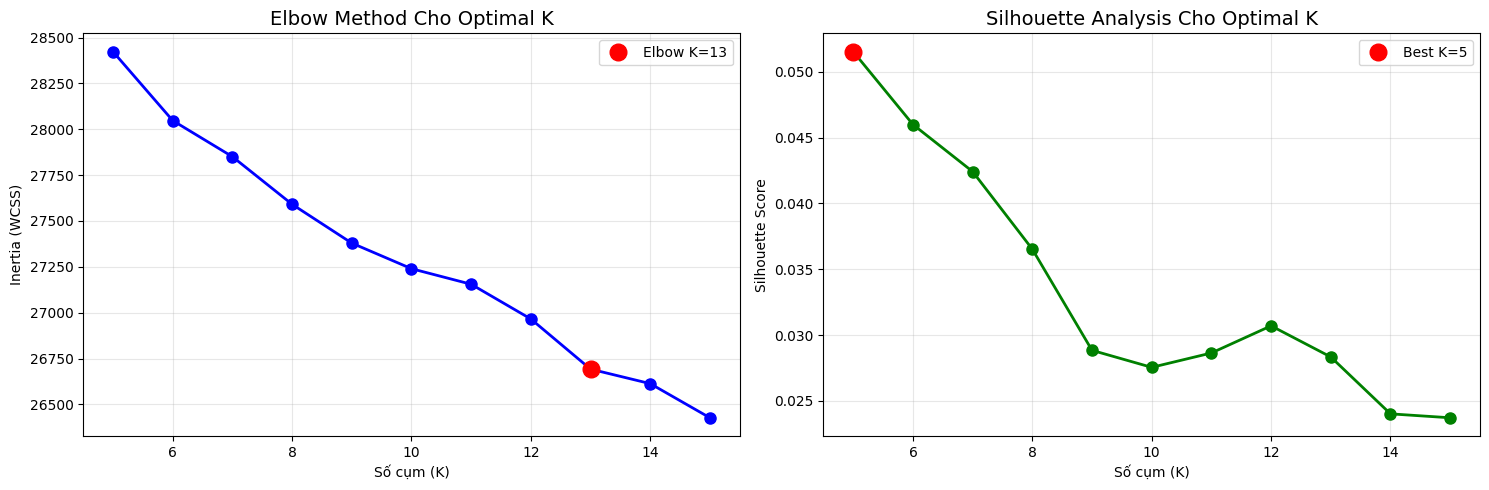


 5. Kết quả chi tiết cho từng K:
--------------------------------------------------
  K |    Inertia | Silhouette
--------------------------------------------------
  5 |      28423 |     0.0515
  6 |      28048 |     0.0460
  7 |      27851 |     0.0424
  8 |      27591 |     0.0365
  9 |      27379 |     0.0288
 10 |      27240 |     0.0276
 11 |      27155 |     0.0286
 12 |      26966 |     0.0307
 13 |      26692 |     0.0283
 14 |      26613 |     0.0240
 15 |      26427 |     0.0237
--------------------------------------------------

 6. Chọn K tối ưu và train model cuối cùng:
    K tối ưu theo Elbow Method: 13
    K tối ưu theo Silhouette Score: 5
    Chọn K = 5 (dựa trên Silhouette Score)

 7. Thông tin kết quả clustering:
    Số cụm: 5
    Silhouette Score: 0.0515
    Tổng sản phẩm: 811

   Phân bố sản phẩm theo cụm:
      Cluster 0: 239 sản phẩm (29.5%)
      Cluster 1: 142 sản phẩm (17.5%)
      Cluster 2: 184 sản phẩm (22.7%)
      Cluster 3: 125 sản phẩm (15.4%)
      Cl

In [19]:
# Bài tập 2.2: Phân cụm dữ liệu Sales Transactions bằng K-means

print(" Bài tập 2.2: Phân cụm dữ liệu Sales Transactions")
print("="*70)

# 1. Tải và khám phá dữ liệu
print(" 1. Tải và khám phá dữ liệu Sales_Transactions_Dataset_Weekly.csv")
# Load dữ liệu
sales_df = pd.read_csv('D:\\Workspace\\HUS\\Machine Learning\\9. Kmeans_DBScan\\Sales_Transactions_Dataset_Weekly.csv')

print(f" Đã tải dữ liệu thành công!")
print(f" Kích thước dữ liệu: {sales_df.shape}")
print(f" Số sản phẩm: {len(sales_df)}")

# Hiển thị thông tin cơ bản về dữ liệu
print(f"\n Thông tin cơ bản về dataset:")
print(f"   - Số dòng: {sales_df.shape[0]}")
print(f"   - Số cột: {sales_df.shape[1]}")

# Hiển thị tên cột
print(f"\n Các cột trong dataset:")
print(sales_df.columns.tolist()[:10], "..." if len(sales_df.columns) > 10 else "")

# Hiển thị 5 dòng đầu
print(f"\n 5 dòng đầu tiên:")
print(sales_df.head())

# 2. Chuẩn bị dữ liệu cho clustering
print(f"\n 2. Chuẩn bị dữ liệu cho clustering:")

# Lấy Product ID
product_ids = sales_df.iloc[:, 0].values
print(f"📦 Số Product ID: {len(product_ids)}")

# Kiểm tra các cột tuần (Week 0 - Week 51)
week_columns = []
normalized_columns = []

for col in sales_df.columns:
    if col.startswith('Week ') or 'week' in col.lower():
        week_columns.append(col)
    elif 'normalized' in col.lower():
        normalized_columns.append(col)

print(f" Tìm thấy {len(week_columns)} cột tuần")
print(f" Tìm thấy {len(normalized_columns)} cột normalized")

# Chọn dữ liệu weekly transactions hoặc normalized
if len(week_columns) >= 52:
    # Sử dụng dữ liệu weekly transactions
    feature_columns = week_columns[:52]  # Lấy 52 tuần đầu
    data_type = "Weekly Transactions"
    print(f" Sử dụng {len(feature_columns)} cột weekly transactions")
elif len(normalized_columns) >= 52:
    # Sử dụng dữ liệu normalized
    feature_columns = normalized_columns[:52]
    data_type = "Normalized Data"
    print(f" Sử dụng {len(feature_columns)} cột normalized data")
else:
    # Lấy tất cả cột số (trừ cột đầu tiên)
    numeric_columns = sales_df.select_dtypes(include=[np.number]).columns.tolist()
    feature_columns = numeric_columns
    data_type = "Numeric Features"
    print(f" Sử dụng {len(feature_columns)} cột số")

# Trích xuất features cho clustering
X_sales = sales_df[feature_columns].values
print(f" Ma trận dữ liệu cho clustering: {X_sales.shape}")

# Kiểm tra missing values
missing_count = np.isnan(X_sales).sum()
if missing_count > 0:
    print(f"  Tìm thấy {missing_count} giá trị missing - sẽ thay bằng 0")
    X_sales = np.nan_to_num(X_sales, 0)

# Chuẩn hóa dữ liệu (StandardScaler)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sales_scaled = scaler.fit_transform(X_sales)
print(f" Đã chuẩn hóa dữ liệu bằng StandardScaler")

print(f"\n Thống kê dữ liệu sau chuẩn hóa:")
print(f"   - Mean: {np.mean(X_sales_scaled):.6f}")
print(f"   - Std: {np.std(X_sales_scaled):.6f}")
print(f"   - Min: {np.min(X_sales_scaled):.2f}")
print(f"   - Max: {np.max(X_sales_scaled):.2f}")

# 3. Tìm số cụm tối ưu (K = 5 đến 15)
print(f"\n 3. Tìm số cụm tối ưu (K từ 5 đến 15):")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Tạo range K từ 5 đến 15
K_range = range(5, 16)
inertias = []
silhouette_scores = []

print(f" Đang test từ K={min(K_range)} đến K={max(K_range)}...")

# Progress bar cho việc tìm K tối ưu
with tqdm(K_range, desc="Tìm K tối ưu") as pbar:
    for k in pbar:
        pbar.set_description(f"Testing K={k}")
        
        # Khởi tạo và fit KMeans
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_sales_scaled)
        
        # Tính inertia (WCSS - Within-Cluster Sum of Squares)
        inertia = kmeans.inertia_
        inertias.append(inertia)
        
        # Tính silhouette score
        silhouette_avg = silhouette_score(X_sales_scaled, labels)
        silhouette_scores.append(silhouette_avg)
        
        pbar.set_postfix({'Inertia': f'{inertia:.0f}', 'Silhouette': f'{silhouette_avg:.4f}'})

print(f" Hoàn thành analysis cho {len(K_range)} giá trị K!")

# 4. Vẽ biểu đồ Elbow Method và Silhouette Analysis
print(f"\n 4. Phân tích Elbow Method và Silhouette Score:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Elbow Method
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method Cho Optimal K', fontsize=14)
ax1.set_xlabel('Số cụm (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True, alpha=0.3)

# Highlight giá trị tốt nhất
best_elbow_idx = np.argmax(np.diff(np.diff(inertias))) + 1  # Second derivative
best_k_elbow = list(K_range)[best_elbow_idx]
ax1.plot(best_k_elbow, inertias[best_elbow_idx], 'ro', markersize=12, label=f'Elbow K={best_k_elbow}')
ax1.legend()

# Plot Silhouette Score
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Analysis Cho Optimal K', fontsize=14)
ax2.set_xlabel('Số cụm (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

# Highlight giá trị tốt nhất
best_silhouette_idx = np.argmax(silhouette_scores)
best_k_silhouette = list(K_range)[best_silhouette_idx]
ax2.plot(best_k_silhouette, silhouette_scores[best_silhouette_idx], 'ro', markersize=12, label=f'Best K={best_k_silhouette}')
ax2.legend()

plt.tight_layout()
plt.show()

# 5. In ra kết quả chi tiết
print(f"\n 5. Kết quả chi tiết cho từng K:")
print("-" * 50)
print(f"{'K':>3} | {'Inertia':>10} | {'Silhouette':>10}")
print("-" * 50)
for i, k in enumerate(K_range):
    print(f"{k:>3} | {inertias[i]:>10.0f} | {silhouette_scores[i]:>10.4f}")
print("-" * 50)

# 6. Chọn K tối ưu và train model cuối cùng
optimal_k_silhouette = best_k_silhouette
print(f"\n 6. Chọn K tối ưu và train model cuối cùng:")
print(f"    K tối ưu theo Elbow Method: {best_k_elbow}")
print(f"    K tối ưu theo Silhouette Score: {optimal_k_silhouette}")
print(f"    Chọn K = {optimal_k_silhouette} (dựa trên Silhouette Score)")

# Train model cuối cùng với K tối ưu
final_kmeans = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
optimal_labels = final_kmeans.fit_predict(X_sales_scaled)
centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)

# Thông tin kết quả
from collections import Counter
cluster_counts = Counter(optimal_labels)

print(f"\n 7. Thông tin kết quả clustering:")
print(f"    Số cụm: {optimal_k_silhouette}")
print(f"    Silhouette Score: {silhouette_scores[best_silhouette_idx]:.4f}")
print(f"    Tổng sản phẩm: {len(optimal_labels)}")

print(f"\n   Phân bố sản phẩm theo cụm:")
for cluster_id in sorted(cluster_counts.keys()):
    count = cluster_counts[cluster_id]
    percentage = (count / len(optimal_labels)) * 100
    print(f"      Cluster {cluster_id}: {count} sản phẩm ({percentage:.1f}%)")

# Lưu model thông tin để sử dụng ở cell tiếp theo
optimal_model = {
    'k': optimal_k_silhouette,
    'labels': optimal_labels,
    'centroids': centroids_original,
    'silhouette': silhouette_scores[best_silhouette_idx],
    'kmeans': final_kmeans
}


 8. Visualization chi tiết của các cụm:
 Explained variance ratio: [0.32149338 0.03587594]
 Total explained variance: 35.7%


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3312\3997668941.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(cluster_transactions, labels=[f'C{i}' for i in range(optimal_k_silhouette)],


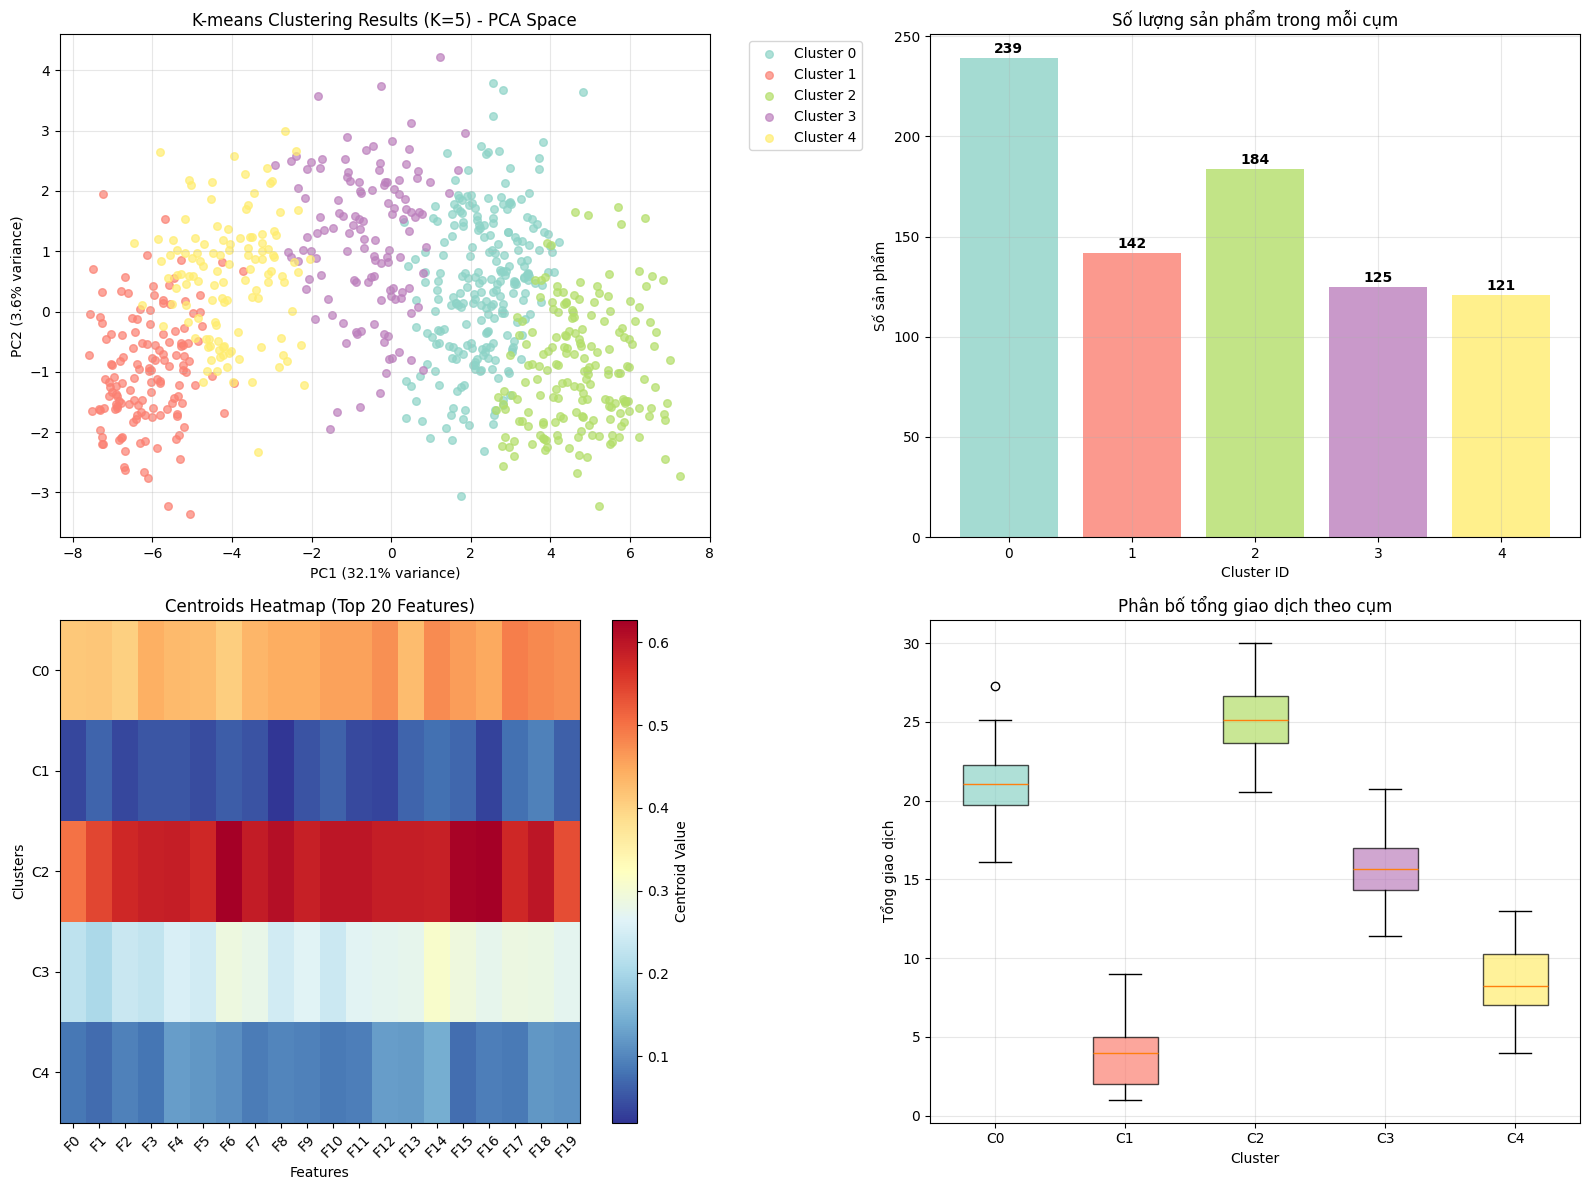


 9. Business Insights và Khuyến nghị:

 Phân tích theo clusters:

    Cluster 0 (239 sản phẩm):
       Trung bình giao dịch: 20.96
       Trung vị giao dịch: 21.02
      Độ lệch chuẩn: 1.92
        Loại:  HIGH-VALUE

    Cluster 1 (142 sản phẩm):
       Trung bình giao dịch: 3.84
       Trung vị giao dịch: 4.00
      Độ lệch chuẩn: 1.72
        Loại:  LOW-VALUE

    Cluster 2 (184 sản phẩm):
       Trung bình giao dịch: 25.13
       Trung vị giao dịch: 25.10
      Độ lệch chuẩn: 2.18
        Loại:  HIGH-VALUE

    Cluster 3 (125 sản phẩm):
       Trung bình giao dịch: 15.61
       Trung vị giao dịch: 15.67
      Độ lệch chuẩn: 2.02
        Loại:  LOW-VALUE

    Cluster 4 (121 sản phẩm):
       Trung bình giao dịch: 8.54
       Trung vị giao dịch: 8.20
      Độ lệch chuẩn: 1.98
        Loại:  LOW-VALUE
 Tóm tắt kết quả:
   Số cụm tối ưu: 5
   Silhouette Score: 0.0515
   Tổng số sản phẩm: 811
   Dữ liệu sử dụng: Normalized Data
   Phương pháp: K-means với StandardScaler
 Các sản phẩm đã

In [20]:
# 8. Visualization chi tiết
print(f"\n 8. Visualization chi tiết của các cụm:")

# PCA để giảm chiều cho visualization
from sklearn.decomposition import PCA

# Giảm xuống 2D để visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sales_scaled)

print(f" Explained variance ratio: {pca.explained_variance_ratio_}")
print(f" Total explained variance: {sum(pca.explained_variance_ratio_):.1%}")

# Tạo visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scatter plot của clusters trong không gian PCA
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k_silhouette))
for cluster_id in range(optimal_k_silhouette):
    cluster_mask = optimal_labels == cluster_id
    axes[0, 0].scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                      c=[colors[cluster_id]], label=f'Cluster {cluster_id}', 
                      alpha=0.7, s=30)

axes[0, 0].set_title(f'K-means Clustering Results (K={optimal_k_silhouette}) - PCA Space', fontsize=12)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bar chart số lượng sản phẩm trong mỗi cụm
cluster_ids = sorted(cluster_counts.keys())
cluster_sizes = [cluster_counts[cid] for cid in cluster_ids]

bars = axes[0, 1].bar(cluster_ids, cluster_sizes, color=colors[:len(cluster_ids)], alpha=0.8)
axes[0, 1].set_title('Số lượng sản phẩm trong mỗi cụm', fontsize=12)
axes[0, 1].set_xlabel('Cluster ID')
axes[0, 1].set_ylabel('Số sản phẩm')
axes[0, 1].grid(True, alpha=0.3)

# Thêm labels trên bars
for bar, size in zip(bars, cluster_sizes):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                   f'{size}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Heatmap của centroids (top 20 features)
top_features = 20
centroid_subset = centroids_original[:, :top_features]
feature_names_subset = [f'F{i}' for i in range(top_features)]

im = axes[1, 0].imshow(centroid_subset, cmap='RdYlBu_r', aspect='auto')
axes[1, 0].set_title(f'Centroids Heatmap (Top {top_features} Features)', fontsize=12)
axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Clusters')
axes[1, 0].set_xticks(range(top_features))
axes[1, 0].set_xticklabels(feature_names_subset, rotation=45)
axes[1, 0].set_yticks(range(optimal_k_silhouette))
axes[1, 0].set_yticklabels([f'C{i}' for i in range(optimal_k_silhouette)])

# Colorbar cho heatmap
plt.colorbar(im, ax=axes[1, 0], label='Centroid Value')

# Plot 4: Distribution của tổng giao dịch theo cụm
total_transactions = np.sum(X_sales, axis=1)  # Tổng giao dịch mỗi sản phẩm

# Boxplot cho mỗi cluster
cluster_transactions = []
for cluster_id in range(optimal_k_silhouette):
    cluster_mask = optimal_labels == cluster_id
    cluster_transactions.append(total_transactions[cluster_mask])

bp = axes[1, 1].boxplot(cluster_transactions, labels=[f'C{i}' for i in range(optimal_k_silhouette)], 
                       patch_artist=True)

# Tô màu cho boxplot
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_title('Phân bố tổng giao dịch theo cụm', fontsize=12)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Tổng giao dịch')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Phân tích business insights
print(f"\n 9. Business Insights và Khuyến nghị:")

print(f"\n Phân tích theo clusters:")
for cluster_id in range(optimal_k_silhouette):
    cluster_mask = optimal_labels == cluster_id
    cluster_transactions = total_transactions[cluster_mask]
    
    avg_transactions = np.mean(cluster_transactions)
    med_transactions = np.median(cluster_transactions)
    std_transactions = np.std(cluster_transactions)
    
    print(f"\n    Cluster {cluster_id} ({cluster_counts[cluster_id]} sản phẩm):")
    print(f"       Trung bình giao dịch: {avg_transactions:.2f}")
    print(f"       Trung vị giao dịch: {med_transactions:.2f}")
    print(f"      Độ lệch chuẩn: {std_transactions:.2f}")
    
    # Phân loại cluster
    if avg_transactions > np.mean(total_transactions):
        category = " HIGH-VALUE"
    elif avg_transactions > np.median(total_transactions):
        category = " MEDIUM-VALUE"
    else:
        category = " LOW-VALUE"
    
    print(f"        Loại: {category}")

print(f"="*70)
print(f" Tóm tắt kết quả:")
print(f"   Số cụm tối ưu: {optimal_k_silhouette}")
print(f"   Silhouette Score: {optimal_model['silhouette']:.4f}")
print(f"   Tổng số sản phẩm: {len(product_ids)}")
print(f"   Dữ liệu sử dụng: {data_type}")
print(f"   Phương pháp: K-means với StandardScaler")
print(f" Các sản phẩm đã được phân thành {optimal_k_silhouette} nhóm dựa trên pattern giao dịch!")